# **Phenotypic Bias in Heart Disease Prediction**
### *Fairness and Explainability Analysis using the UCI Heart Disease Dataset (Cleveland)*

**Author:** Francisca Mihalache  
**Course:** Artificial Intelligence and Society — Individual Assignment 

The dataset used in this analysis originates from the Cleveland Clinic cohort of 303 consecutive patients referred for coronary angiography between May 1981 and September 1984, as described by Detrano et al. (1989).
Each patient underwent a detailed clinical assessment including age, sex, chest pain type, systolic blood pressure, serum cholesterol, fasting blood sugar, resting ECG, and three noninvasive tests: exercise electrocardiogram, thallium scintigraphy, and cardiac fluoroscopy.
These data were collected under controlled conditions and entered into a computerized database, forming the reference group used to derive the Cleveland discriminant function for coronary artery disease (CAD) diagnosis

### **Objective**
This notebook explores potential *phenotypic bias* in heart disease prediction models by analyzing whether performance differs across chest pain types (`cp`) — *typical angina*, *atypical angina*, *non-anginal pain*, and *asymptomatic* — in the **UCI Heart Disease (Cleveland)** dataset.  

The study integrates two key Responsible AI dimensions:  
- **Fairness:** evaluating performance disparities between clinical subgroups.  
- **Explainability:** using SHAP values to understand which features contribute to those differences.  

Results are discussed from both a **technical** and **ethical** standpoint, reflecting on possible subdiagnosis risks for patients with less typical symptoms.

This analysis adopts a **Data-Centric AI** perspective, emphasizing that model reliability depends primarily on the *quality, representativeness, and interpretability of data* rather than on algorithmic complexity.  
The approach follows the principle of transforming **imperfect data into smart data**, by systematically inspecting and improving dataset characteristics such as *completeness*, *balance*, and *fair representation*.

Within this paradigm, data irregularities are not seen as noise to be ignored but as signals that reveal deeper structural issues — for example, **phenotypic imbalance** (differences across chest pain types) and **demographic skew** (sex-based disparities).  
By addressing these *data intrinsic characteristics*, the study aligns with the notion that responsible AI requires continuous *data auditing, transparency, and human-in-the-loop validation*.  
This mindset connects directly to the broader Responsible AI dimensions of *fairness* and *explainability*, ensuring that the learning process reflects medical and ethical understanding rather than statistical convenience.

The Cleveland dataset also illustrates key **data complexity factors**, since multiple irregularities coexist — mild imbalance, missingness, and overlapping phenotypes.  
Such intertwined characteristics increase the **instance hardness** of medical prediction, a concept central to understanding why models may fail to generalize across underrepresented patient subgroups.

### Table of Contents

1. [Dataset Background and Structure](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Data Preprocessing](#3)
4. [Model Training](#4)
5. [Fairness Analysis by Chest Pain Type](#5)
6. [Explainability Analysis (SHAP)](#6)
7. [Ethical Reflection and Discussion](#7)
8. [Conclusions](#8)
9. [References](#9)

#### Environment Setup


In [1]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Imports

In [2]:
from ucimlrepo import fetch_ucirepo 
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import pandas as pd
import missingno as msno



<a id="1"></a>
## 1. Dataset Background and Structure



#### 1.1 Dataset Loading and Description
We fetch the UCI Heart Disease (Cleveland) dataset using the ucimlrepo package.
The dataset includes 303 patients and 13 clinical features related to cardiovascular risk.

In [3]:

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Data as pandas DataFrames
X = heart_disease.data.features
y = heart_disease.data.targets

# Display concise metadata
meta_df = pd.DataFrame(list(heart_disease.metadata.items()), columns=["Key", "Value"])
display(meta_df)  

# Display only first 10 variable descriptions
display(heart_disease.variables)

,Key,Value
0,uci_id,45
1,name,Heart Disease
2,repository_url,https://archive.ics.uci.edu/dataset/45/heart+d...
3,data_url,https://archive.ics.uci.edu/static/public/45/d...
4,abstract,"4 databases: Cleveland, Hungary, Switzerland, ..."
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,303
9,num_features,13


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


The tables above summarize the **dataset metadata** and the **full list of variables** retrieved from the UCI Machine Learning Repository.  
The original code example from the `ucimlrepo` documentation was slightly modified to present the information in a more compact and structured way.

From the **metadata table**, we confirm that:

- **Task type:** Classification (predicting presence of heart disease)  
- **Instances:** 303 patients  
- **Features:** 13 clinical attributes (a mix of categorical, integer, and real types)  
- **Demographic variables:** Age and Sex  
- **Target variable:** `num` — ranges from 0 (no disease) to 4 (presence of disease)  
- **Missing values:** Yes — represented as `NaN`  
- **Dataset creation year:** 1989, updated in 2023  
- **Creators:** Andras Janosi, William Steinbrunn, Matthias Pfisterer, Robert Detrano  
- **DOI:** [10.24432/C52P4X](https://doi.org/10.24432/C52P4X)  
- **Repository link:** [UCI Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

From the **variable table**, we can summarize:
- There are 13 input features (`age`, `sex`, `cp`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, `thal`) and 1 target variable (`num`).  
- Most features are either **integer** or **categorical**, aligning with clinical measurements and diagnostic categories.  
- The `cp` (chest pain type) variable is especially important for this project — it differentiates patients by pain presentation (*typical angina*, *atypical angina*, *non-anginal pain*, *asymptomatic*) and will be used to study *phenotypic bias*.  
- The variables `ca` (number of major vessels) and `thal` contain missing values.  
- Descriptive units include `mm Hg` (for blood pressure) and `mg/dl` (for cholesterol).  

This metadata inspection confirms that the dataset is well-suited for the intended analysis on **fairness** and **explainability**.  

Next, we proceed to **data preprocessing**, where the target variable will be binarized and missing values will be handled before training the classification models.


### 1.2 Variable Definitions

According to the official documentation provided by the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease), the Heart Disease (Cleveland) dataset includes **14 clinical attributes** originally described by *Detrano et al. (1989)* in the *American Journal of Cardiology*.  

The variable definitions are summarized below and will be considered throughout this study for proper interpretation and clinical consistency.

| Feature | Description | Type / Units | Encoded Values |
|----------|--------------|---------------|----------------|
| **age** | Age of the patient | Integer / years | — |
| **sex** | Biological sex | Categorical | 1 = male, 0 = female |
| **cp** | Chest pain type | Categorical | 1 = typical angina<br>2 = atypical angina<br>3 = non-anginal pain<br>4 = asymptomatic |
| **trestbps** | Resting blood pressure (on hospital admission) | Integer / mm Hg | — |
| **chol** | Serum cholesterol level | Integer / mg/dl | — |
| **fbs** | Fasting blood sugar > 120 mg/dl | Categorical | 1 = true, 0 = false |
| **restecg** | Resting electrocardiographic results | Categorical | 0 = normal<br>1 = ST–T abnormality<br>2 = left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved | Integer / bpm | — |
| **exang** | Exercise-induced angina | Categorical | 1 = yes, 0 = no |
| **oldpeak** | ST depression induced by exercise relative to rest | Float | — |
| **slope** | Slope of the peak exercise ST segment | Categorical | 1 = upsloping<br>2 = flat<br>3 = downsloping |
| **ca** | Number of major vessels colored by fluoroscopy | Integer (0–3) | — |
| **thal** | Thalassemia | Categorical | 3 = normal<br>6 = fixed defect<br>7 = reversible defect |
| **num** | Diagnosis of heart disease (angiographic disease status) | **Target variable** | 0 = no disease (< 50 % narrowing)<br>1–4 = disease present (> 50 % narrowing) |

These definitions form the foundation of all subsequent analyses.  
They ensure that feature interpretations and clinical reasoning remain consistent with the original dataset documentation and medical context.


## 2. Exploratory Data Analysis (EDA)

After loading and describing the dataset, we now explore its main statistical properties and internal patterns to better understand how the features are distributed.

#### 2.1 General Information

In [4]:
X.info()

# Quick view of numeric variables
X.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


The dataset consists of **303 patient records** and **13 measurable features** related to cardiovascular health.  
All variables are numeric, meaning that categorical features (such as `sex`, `cp`, `restecg`, and `slope`) are encoded as integers.  
This numeric representation simplifies model training but requires semantic remapping later for clearer interpretation.  

Two variables, `ca` (number of major vessels) and `thal` (thalassemia type), contain a small number of missing values.  
These missing entries will be imputed before training to ensure data consistency.  

At this point, the dataset appears well-structured and suitable for the upcoming analyses.  
The next steps will focus on exploring distributions, feature relationships, and possible data imbalances that may affect fairness across patient subgroups.


#### 2.2 Missing Values

In [5]:
# Check for missing data
missing_summary = X.isna().sum()
missing_summary[missing_summary > 0]

ca      4
thal    2
dtype: int64

As confirmed earlier in the variable table, only two features contain missing values: `ca` (number of major vessels) with **4 missing entries**, and `thal` (thalassemia type) with **2 missing entries**.  The number of missing values is very small compared to the dataset size, so these can be safely imputed later without affecting the statistical integrity of the data.


=== Heart Disease Case Distribution ===
0 (No disease):  164 patients
1 (Has disease): 139 patients
Total:            303 patients


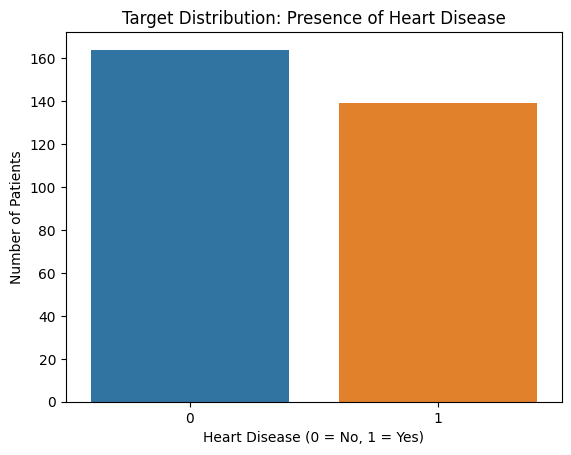

In [6]:
# Convert the target variable to binary: 0 = No disease, 1 = Disease present
y_binary = y['num'].apply(lambda v: 1 if v > 0 else 0)

# Count the number of patients in each class
class_counts = y_binary.value_counts().sort_index()

# Print the class distribution
print("=== Heart Disease Case Distribution ===")
print(f"0 (No disease):  {class_counts[0]} patients")
print(f"1 (Has disease): {class_counts[1]} patients")
print(f"Total:            {class_counts.sum()} patients")

# Visualize the distribution
sns.countplot(x=y_binary, palette=['#1f77b4', '#ff7f0e'])
plt.title('Target Distribution: Presence of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()


This near-balanced distribution (54% vs. 46%) indicates that class imbalance is minimal, allowing models to be trained and evaluated without requiring rebalancing techniques.  

In this context, techniques such as **SMOTE** or other oversampling methods are unnecessary and could even introduce artificial patterns not grounded in clinical reality.  
Following the *Data-Centric AI* rationale, data balance should be evaluated in relation to its **semantic validity** rather than applied mechanically.  
Since the Cleveland dataset already maintains a near-balanced distribution between healthy and diseased cases, preserving its natural proportions ensures more **faithful and interpretable** model behavior.


#### 2.3 Chest Pain Type Distribution (cp)

Here we examine how the four **chest pain types (`cp`)** are distributed across the dataset.  
This helps identify possible **phenotypic imbalance**, for example, whether some clinical presentations are much more common than others, which could later influence model fairness.

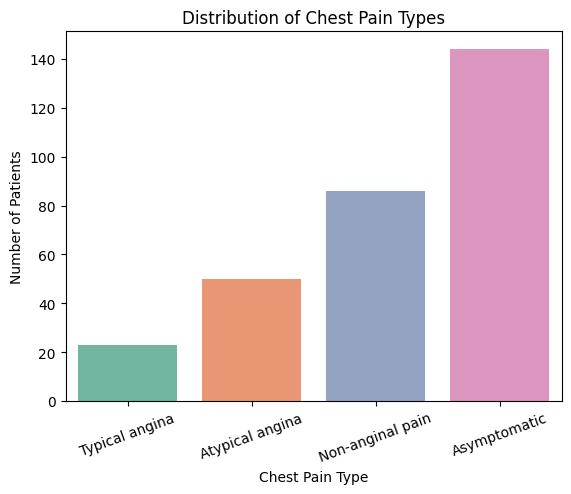

Chest Pain Type Counts:
cp_label
Asymptomatic        144
Non-anginal pain     86
Atypical angina      50
Typical angina       23
Name: count, dtype: int64


In [7]:
# Map chest pain codes to labels
cp_mapping = {1: 'Typical angina', 2: 'Atypical angina', 3: 'Non-anginal pain', 4: 'Asymptomatic'}
X['cp_label'] = X['cp'].map(cp_mapping)

# Plot distribution of chest pain types
sns.countplot(x='cp_label', data=X, order=cp_mapping.values(), palette='Set2')
plt.title('Distribution of Chest Pain Types')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=20)
plt.show()

# Print exact counts
print("Chest Pain Type Counts:")
print(X['cp_label'].value_counts())


The counts show that most patients are **asymptomatic (144)**, followed by **non-anginal pain (86)**,  
while **typical angina (23)** is the least frequent.  
This uneven distribution confirms the presence of **phenotypic imbalance**, meaning that models trained on this dataset may learn patterns dominated by asymptomatic and non-anginal cases.

The four chest pain categories used in the Cleveland dataset follow the clinical definitions adopted by Detrano et al. (1989):
typical angina, atypical angina, non-anginal pain, and asymptomatic.
This classification was a key clinical variable in the original study, as chest pain presentation was one of the most informative predictors of coronary artery disease.
However, Detrano et al. noted that even asymptomatic and non-anginal patients could show significant angiographic abnormalities, revealing potential diagnostic bias when relying only on symptoms

#### 2.4 Chest Pain Type vs. Sex

This table compares **chest pain types (`cp`)** between **male** and **female** patients.  
By observing these distributions, we can check whether certain pain types are more frequent in one sex — a relevant factor in understanding possible **gender-related diagnostic bias**.


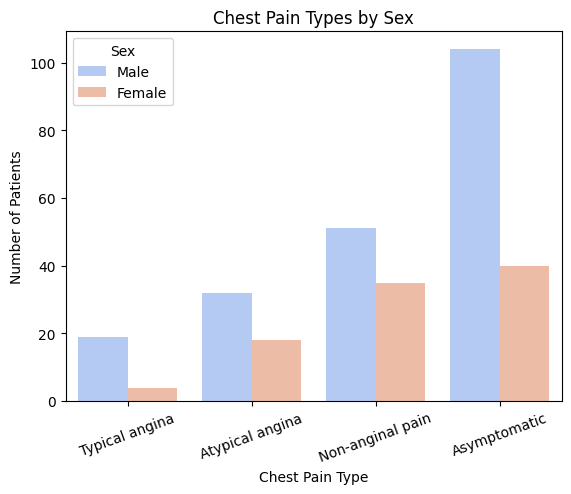

sex_label,Female,Male
cp_label,,
Asymptomatic,40,104
Atypical angina,18,32
Non-anginal pain,35,51
Typical angina,4,19


In [8]:
# Replace sex with readable labels
X['sex_label'] = X['sex'].map({0: 'Female', 1: 'Male'})

# Cross-tab and plot
sns.countplot(data=X, x='cp_label', hue='sex_label', order=cp_mapping.values(), palette='coolwarm')
plt.title('Chest Pain Types by Sex')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.legend(title='Sex')
plt.xticks(rotation=20)
plt.show()

# Print counts
pd.crosstab(X['cp_label'], X['sex_label'])


The results show that **men** dominate all categories, especially *asymptomatic* and *typical angina* cases.  
**Women** are proportionally more represented in *non-anginal pain* and *atypical angina*,  
indicating that their symptoms tend to be less typical — a pattern consistent with real-world clinical evidence of sex-based differences in heart disease presentation.

#### 2.5 Age Distribution by Sex

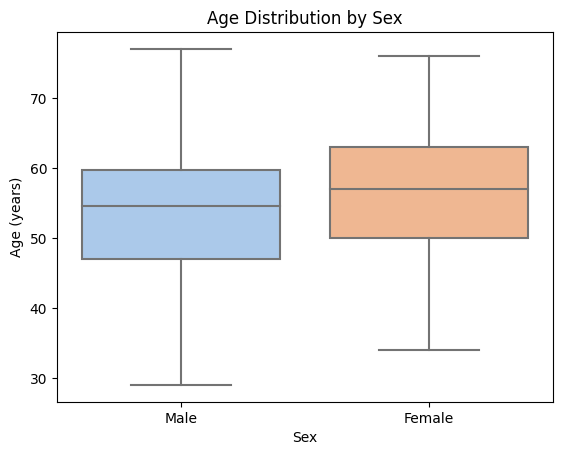

                mean       std   min   max
sex_label                                 
Female     55.721649  9.370546  34.0  76.0
Male       53.834951  8.836838  29.0  77.0


In [9]:
sns.boxplot(x='sex_label', y='age', data=X, palette='pastel')
plt.title('Age Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Age (years)')
plt.show()

print(X.groupby('sex_label')['age'].describe()[['mean', 'std', 'min', 'max']])


The boxplot and summary statistics show that **female patients** have a slightly higher mean age (≈55.7 years) than **male patients** (≈53.8 years).  
This reflects real-world clinical patterns, where women tend to develop heart disease later in life compared to men.

#### 2.6 Correlation Matrix (Numeric Variables)

The heatmap displays pairwise correlations between all numerical features.  

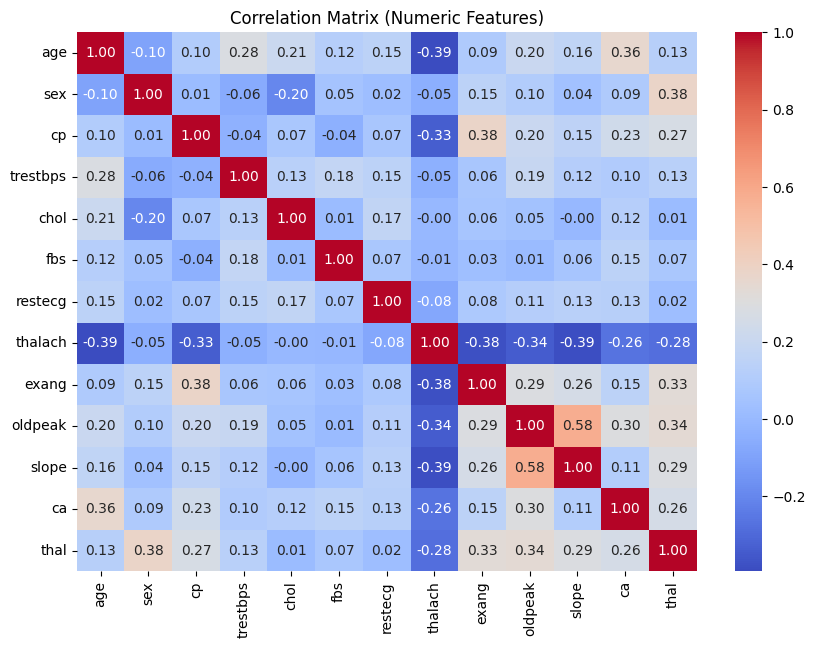

In [10]:
corr = X.corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix (Numeric Features)')
plt.show()



Strong negative correlations are observed between **age** and **thalach** (−0.39), indicating that older patients generally reach lower maximum heart rates.  
There is also moderate correlation between **oldpeak** and **slope** (≈0.58), consistent with how ST segment depression relates to exercise intensity.  
No extreme multicollinearity is detected, suggesting that all variables can be safely used in modeling.

#### 2.7 Pairplot 
The pairplot visualizes pairwise relationships between several numeric features, colored by **chest pain type (`cp`)**.  

/Users/franciscamihalache/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/franciscamihalache/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/franciscamihalache/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/franciscamihalache/L

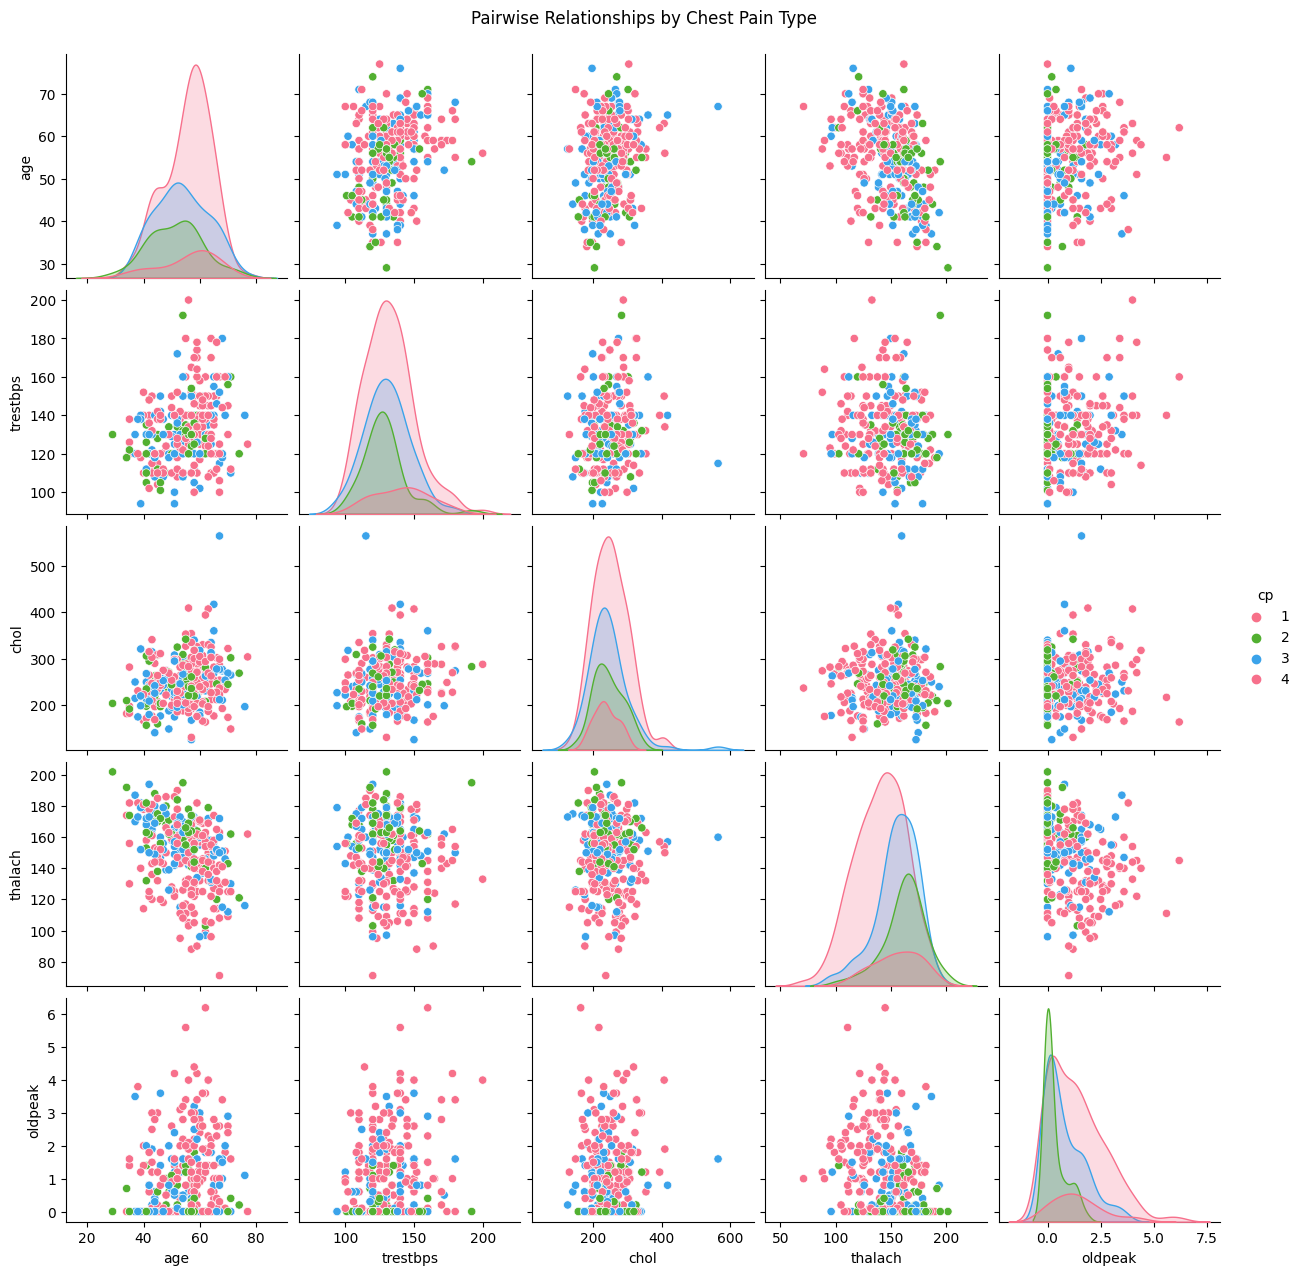

In [11]:
sns.pairplot(X[['age','trestbps','chol','thalach','oldpeak','cp']], diag_kind='kde', hue='cp', palette='husl')
plt.suptitle('Pairwise Relationships by Chest Pain Type', y=1.02)
plt.show()


In general, *asymptomatic* patients (red points) tend to have **higher blood pressure and cholesterol**, which often corresponds to people who have underlying cardiovascular problems but do not feel obvious pain.  
In contrast, those with *typical angina* (blue) usually have **clearer symptoms during effort** and show signs of better heart function, such as higher maximum heart rate and lower exercise-related stress (`oldpeak`).  

These patterns mirror what happens in real life: patients with fewer or no symptoms can still have more severe disease, which explains why models trained only on symptom intensity might misjudge these silent cases.  

This medical imbalance underlies the motivation for studying **phenotypic bias**.

#### 2.8 Missing Data Heatmap

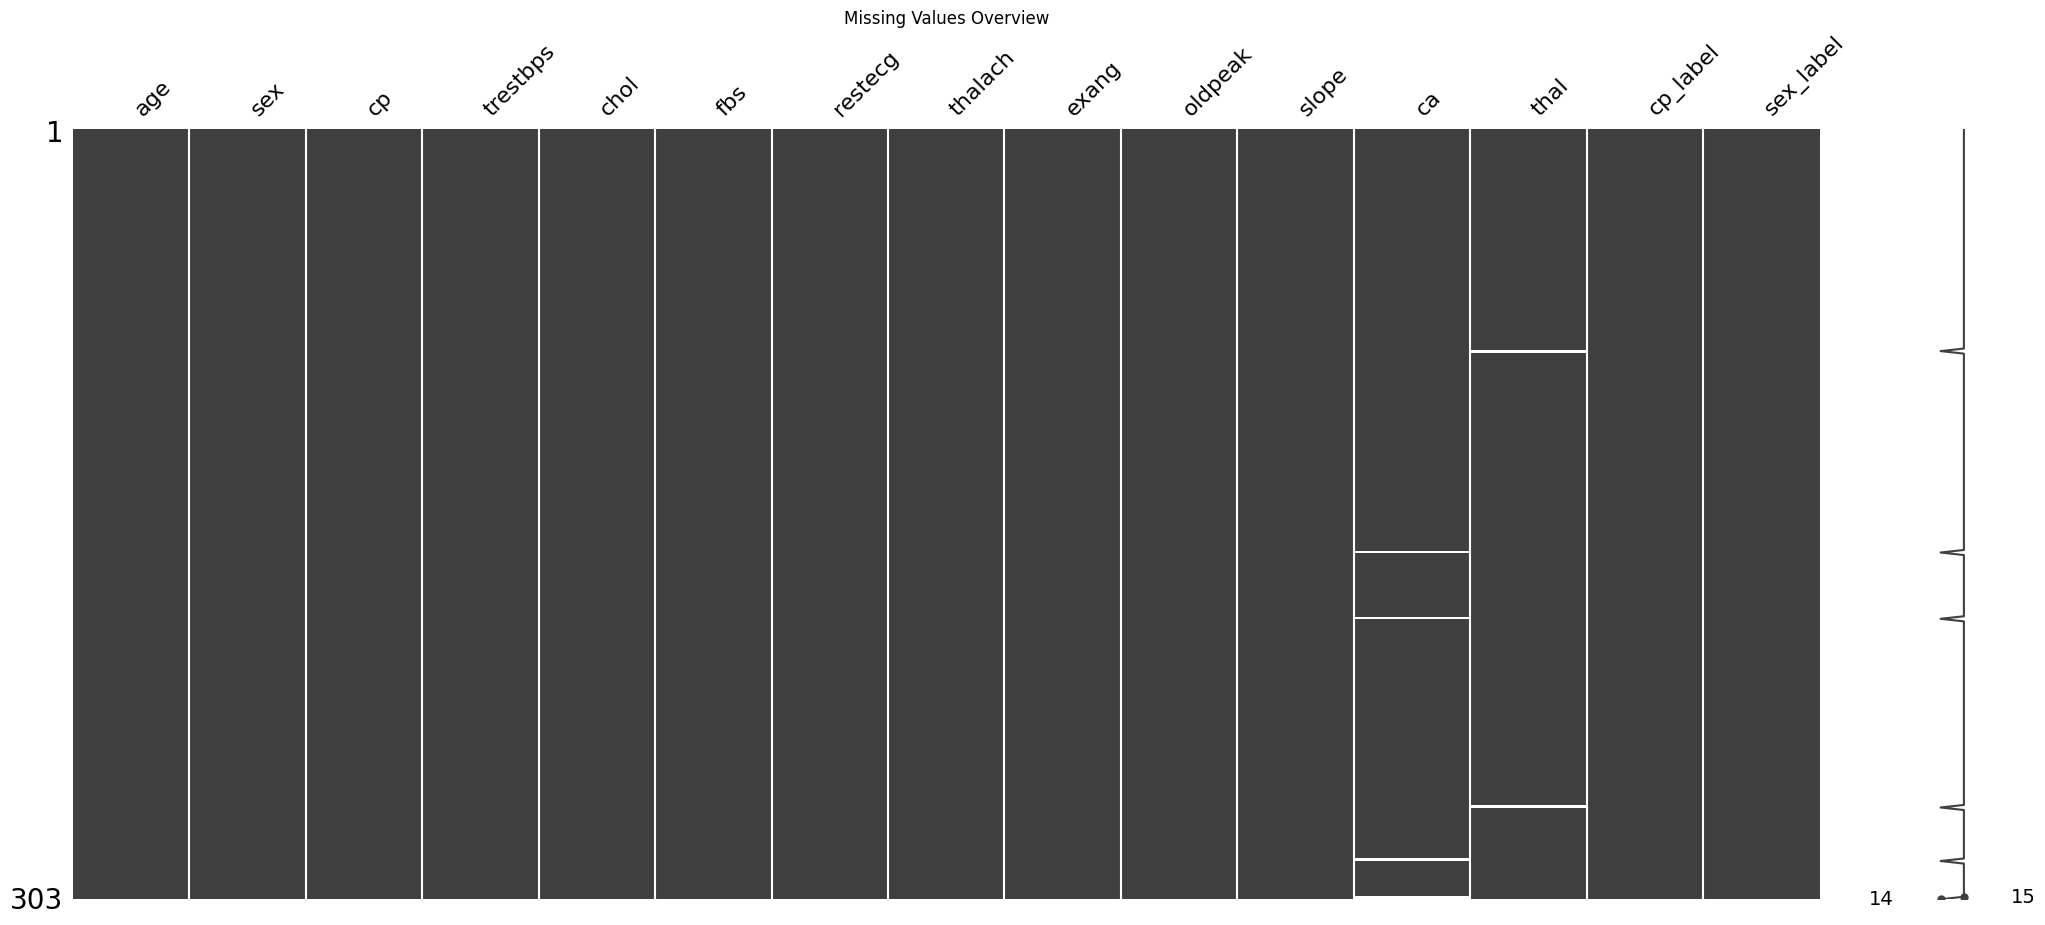

In [12]:
msno.matrix(X)
plt.title('Missing Values Overview')
plt.show()


The heatmap confirms that almost all variables are complete, except for a few missing entries in `ca` and `thal`.  
This matches previous findings and confirms that missing data is minimal and localized,  
making simple imputation a suitable preprocessing strategy.

#### 2.9 Feature Distributions by Disease Status


The boxplots compare key numeric variables between patients **with** and **without** heart disease.  

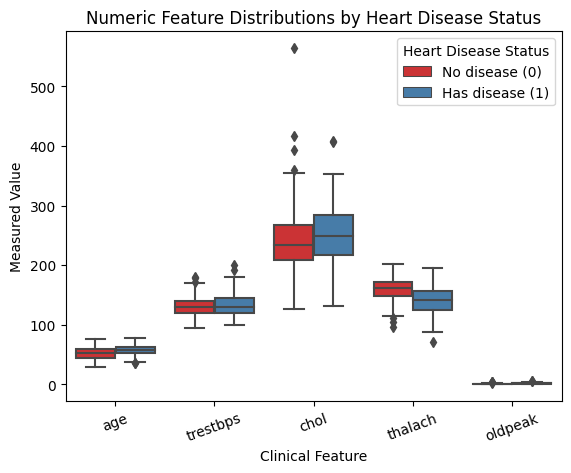

In [13]:
# Copy data and add binary target
df = X.copy()
df['Heart Disease'] = y_binary.map({0: 'No disease (0)', 1: 'Has disease (1)'})

# Select numeric features
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Reshape for plotting
df_melted = df.melt(id_vars='Heart Disease', value_vars=numeric_features,
                    var_name='Feature', value_name='Value')

# Boxplot
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='Heart Disease', palette='Set1')
plt.title('Numeric Feature Distributions by Heart Disease Status')
plt.xlabel('Clinical Feature')
plt.ylabel('Measured Value')
plt.xticks(rotation=20)
plt.legend(title='Heart Disease Status')
plt.show()



Those diagnosed with the condition generally have **lowerThis plot compares several health indicators between patients **with** and **without** heart disease.  
People diagnosed with heart disease (blue boxes) tend to have:
- Lower maximum heart rate (`thalach`), meaning their heart cannot reach high activity levels;
- Higher `oldpeak` values, which reflect greater stress during exercise tests;
- Slightly higher cholesterol (`chol`) and resting blood pressure (`trestbps`).

These differences are consistent with how heart disease usually appears in practice patients with cardiovascular problems often have limited heart performance and higher blood pressure or cholesterol.  

This confirms that the dataset captures realistic physiological differences between healthy and affected individuals.


#### 2.10 Heart Disease Prevalence by Chest Pain Type

This plot examines the **proportion of patients with heart disease** within each chest pain category.  
It helps identify whether certain pain types — such as *asymptomatic* or *non-anginal* — are associated with higher disease prevalence, which is central to understanding **phenotypic bias**.


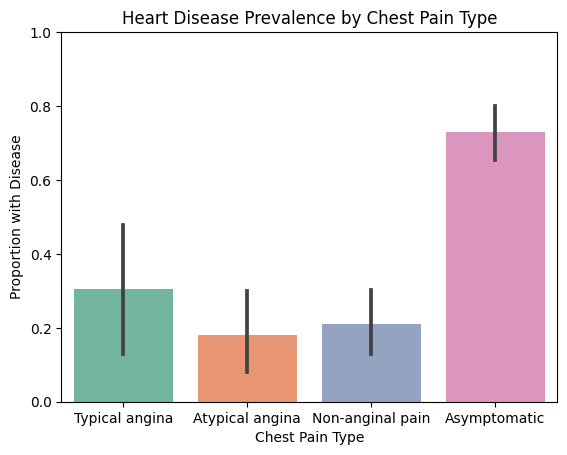

In [14]:
df['Heart Disease Num'] = df['Heart Disease'].map({'Has disease (1)': 1, 'No disease (0)': 0})


sns.barplot(
    data=df,
    x='cp_label',
    y='Heart Disease Num',
    order=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'],
    palette='Set2',
    estimator='mean'
)
plt.title('Heart Disease Prevalence by Chest Pain Type')
plt.ylabel('Proportion with Disease')
plt.xlabel('Chest Pain Type')
plt.ylim(0, 1)
plt.show()


As seen, **asymptomatic patients** have the highest prevalence (around 75%), while **typical angina** and **atypical angina** show much lower rates (below 30%).  
This means that people who **do not experience clear pain** are often the ones **with the most severe disease**. A silent but dangerous pattern also described in the clinical literature.  

It highlights how relying only on pain as a symptom can lead to underdiagnosis of serious cases.

#### 2.11 Age Distribution by Chest Pain Type

This plot compares **age** across the four chest pain types.  
It helps determine whether older patients are more likely to present atypical or asymptomatic pain,  
which can contribute to bias when models rely on symptoms rather than physiological measures.

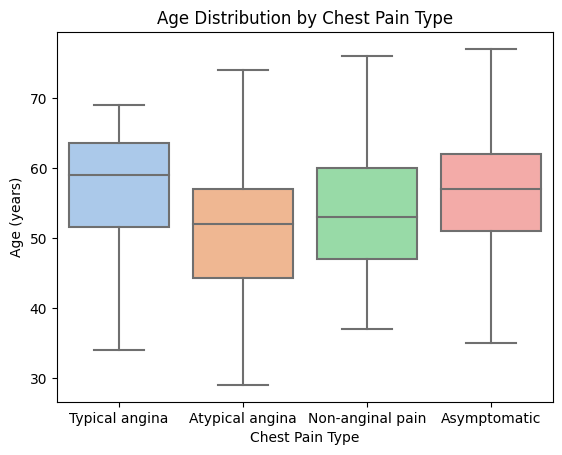

In [15]:
sns.boxplot(
    data=df,
    x='cp_label',
    y='age',
    order=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'],
    palette='pastel'
)
plt.title('Age Distribution by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Age (years)')
plt.show()



The boxplots indicate that **asymptomatic** and **typical angina** patients are generally older, while **atypical** and **non-anginal pain** groups include younger individuals.  

This aligns with the fact that **age increases the risk** of coronary artery disease, and that older patients often develop **fewer or atypical symptoms**, which complicates early detection.

#### 2.12 Sex Distribution by Heart Disease Status

This plot visualizes how **male** and **female** patients are distributed across heart disease outcomes.  
It highlights potential **gender imbalances**, which may affect both medical interpretation and model fairness.


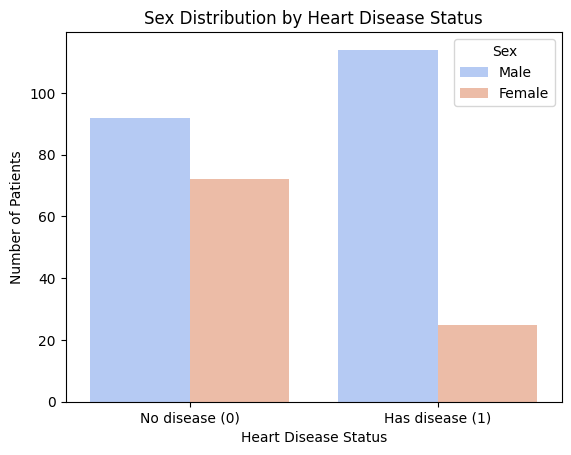

In [16]:
sns.countplot(
    data=df,
    x='Heart Disease',
    hue='sex_label',
    palette='coolwarm'
)
plt.title('Sex Distribution by Heart Disease Status')
plt.xlabel('Heart Disease Status')
plt.ylabel('Number of Patients')
plt.legend(title='Sex')
plt.show()


This bar chart shows that **men** represent the majority of patients, especially among those diagnosed with heart disease.

Women appear less frequently in the dataset and tend to have **atypical or asymptomatic pain**, a pattern consistent with medical findings: heart disease in women is often **under-recognized** because symptoms differ from those in men.

#### 2.13 Age vs. Maximum Heart Rate (thalach)

This scatter plot explores the relationship between **age** and **maximum heart rate achieved**,  
colored by heart disease status.  
It provides insight into how cardiovascular performance decreases with age,  
and whether this decline differs between healthy and affected individuals.


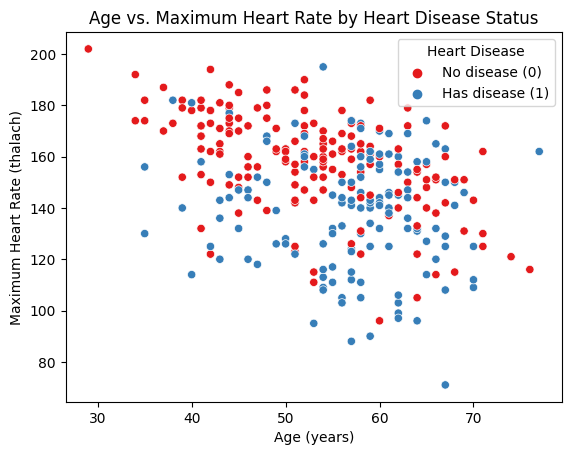

In [17]:
sns.scatterplot(
    data=df,
    x='age',
    y='thalach',
    hue='Heart Disease',
    palette='Set1'
)
plt.title('Age vs. Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Age (years)')
plt.ylabel('Maximum Heart Rate (thalach)')
plt.show()


The scatter plot shows a clear negative relationship between **age** and **maximum heart rate** : older patients naturally reach lower heart rates during exercise.  

Those **with heart disease** (blue points) usually achieve **lower heart rates** than healthy individuals, indicating reduced cardiovascular efficiency and confirming expected physiological decline with disease severity.

#### 2.14 Exercise Stress (oldpeak) by Chest Pain Type

This boxplot compares the **ST depression (`oldpeak`)** among different chest pain types.  
Higher `oldpeak` values usually indicate greater exercise-induced stress on the heart,  
making it an important clinical indicator for disease severity.


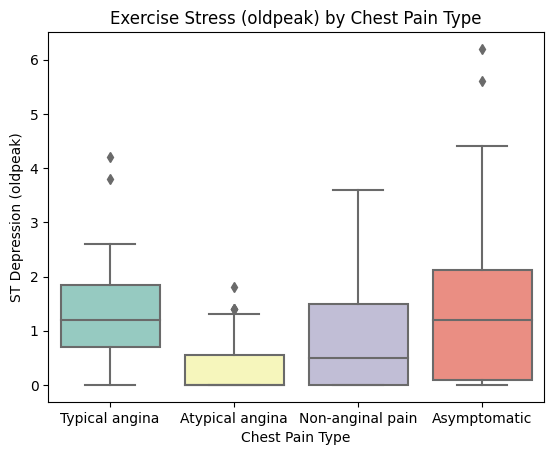

In [18]:
sns.boxplot(
    data=df,
    x='cp_label',
    y='oldpeak',
    order=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'],
    palette='Set3'
)
plt.title('Exercise Stress (oldpeak) by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('ST Depression (oldpeak)')
plt.show()



This boxplot compares exercise-induced stress (ST depression, measured as `oldpeak`) across chest pain categories.  

**Asymptomatic** patients show the **highest oldpeak values**, meaning their hearts experience stronger stress during exercise despite the absence of pain.  

This paradox: severe physiological stress with no pain reinforces the concern that **silent or atypical cases** may represent advanced but undetected heart disease.

#### 2.15 Resting ECG Results by Heart Disease Status

This plot examines how **resting electrocardiogram (ECG) results** (`restecg`) relate to heart disease presence.  

In the Cleveland study (Detrano et al., 1989), this variable was one of the original predictors used to estimate the probability of coronary artery disease.  

Although not highly discriminative on its own, ECG patterns, particularly **ST–T abnormalities** and **left ventricular hypertrophy**, were found to add diagnostic value when combined with exercise-related features.


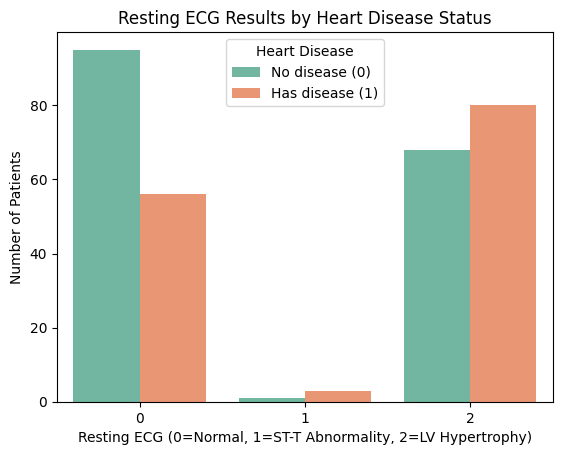

In [19]:
sns.countplot(data=df, x='restecg', hue='Heart Disease', palette='Set2')
plt.title('Resting ECG Results by Heart Disease Status')
plt.xlabel('Resting ECG (0=Normal, 1=ST-T Abnormality, 2=LV Hypertrophy)')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease')
plt.show()


The **resting electrocardiogram (ECG)** measures the heart’s electrical activity at rest.  
In this dataset, the variable `restecg` has three categories:

- **0 = Normal ECG:** No significant electrical abnormalities.  
- **1 = ST–T Abnormality:** Distorted ST or T waves, often signaling ischemia or lack of oxygen supply.  
- **2 = Left Ventricular Hypertrophy (LVH):** Enlargement of the left ventricle, typically due to prolonged high blood pressure.

The plot shows that patients with **LV hypertrophy (code 2)** or **ST–T abnormalities (code 1)** are more likely to have heart disease than those with normal readings.  

While most patients in the dataset fall into the “normal” or “LVH” categories, the **disease ratio rises sharply** for the latter.

This matches the findings of **Detrano et al. (1989)**, who noted that although ECG data alone were not the most powerful predictor, they provided *baseline evidence of structural or electrical stress on the heart* that complemented other noninvasive indicators (exercise ECG, thallium scans, and fluoroscopy).

#### 2.16 Resting Blood Pressure vs. Maximum Heart Rate by Heart Disease Status

This scatter plot explores the relationship between **resting blood pressure (`trestbps`)** and **maximum heart rate achieved (`thalach`)** during exercise.  
Detrano et al. (1989) found that these two measurements, when analyzed jointly with age,  
were significant in distinguishing between healthy and diseased patients — reflecting both cardiovascular efficiency and response to stress.


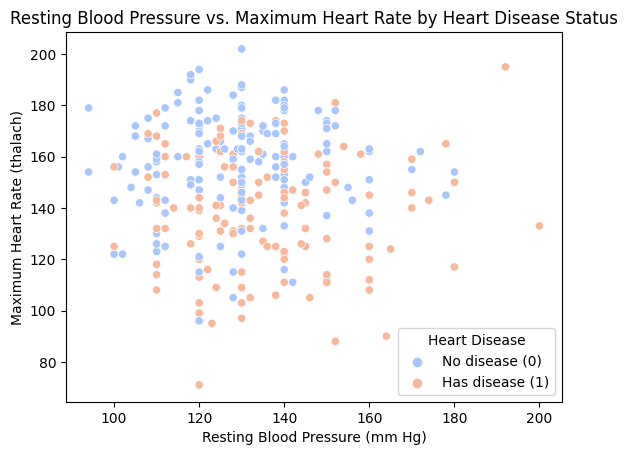

In [20]:
sns.scatterplot(data=df, x='trestbps', y='thalach', hue='Heart Disease', palette='coolwarm')
plt.title('Resting Blood Pressure vs. Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Maximum Heart Rate (thalach)')
plt.show()


This scatter plot compares **resting systolic blood pressure (`trestbps`)**, measured in mmHg at hospital admission, 
with the **maximum heart rate achieved (`thalach`)** during the exercise test.  

In a healthy cardiovascular system:
- Blood pressure at rest tends to stay moderate (around 120 mmHg).  
- The heart rate rises efficiently during exercise (high `thalach` values).  

The pattern seen here reflects the opposite trend for patients with heart disease: those with **higher resting blood pressure** tend to achieve **lower maximum heart rates**.  

They cluster in the upper-left region of the chart (high pressure, low performance),  
indicating **limited cardiac efficiency** and possible arterial stiffness.

This physiological relationship was central to the Cleveland study, **Detrano et al. (1989)** reported that age, resting blood pressure, and exercise capacity together formed a powerful combination for predicting angiographically confirmed coronary artery disease (CAD).  

These results visually confirm that the same hemodynamic imbalance persists in this dataset.

## 3. Data Preprocessing

Before modeling, it is essential to clean and standardize the dataset to ensure that no technical artifacts influence the fairness or explainability analysis. 

Following the original methodology described by **Detrano et al. (1989)**, data preprocessing involves imputing missing values, transforming categorical variables, and normalizing continuous features while preserving their clinical meaning.  
This step ensures the input data remain consistent with the structure of the Cleveland diagnostic model.

These preprocessing steps are not just technical adjustments but deliberate **data-centric interventions** aimed at improving dataset reliability.  
Following the *DC-AI principle of continuous data improvement*, each transformation — from imputing missing values to scaling continuous features — is guided by domain knowledge rather than automated heuristics.  
This aligns with the notion that high-quality, interpretable data form the foundation of trustworthy AI systems.


#### 3.1 Handling Missing Values

In the original Cleveland study (Detrano et al., 1989), these variables correspond to the three non-invasive diagnostic tests performed on all patients:
- `oldpeak` — exercise electrocardiogram (ST depression)
- `thal` — thallium scintigraphy
- `ca` — cardiac fluoroscopy (number of calcified vessels)

The results of these tests were **not used to guide clinical decisions**, as angiography remained the gold standard.  
Their inclusion here allows the model to simulate the same diagnostic reasoning process analyzed by Detrano et al. (1989).  

Imputing missing values in `ca` and `thal` ensures these critical imaging indicators are preserved for the fairness and explainability analysis.

Because missingness is limited and likely not systematic (no demographic pattern observed), we replace missing entries with their **mode values** to preserve distributional integrity.


In [21]:
df.fillna({'ca': df['ca'].mode()[0], 'thal': df['thal'].mode()[0]}, inplace=True)

print("Missing values after imputation:")
print(df[['ca', 'thal']].isna().sum())

Missing values after imputation:
ca      0
thal    0
dtype: int64


#### 3.2 Target Variable Transformation

In the original Cleveland dataset, the variable `num` ranges from 0 to 4, indicating the **severity of coronary artery narrowing** (_0 = no disease_, _4 = severe disease_), as defined by Detrano et al. (1989).  

For modeling purposes, we create a new binary target variable that captures **disease presence** rather than severity.  
Values 1–4 are grouped as _“disease present”_ (`1`), while 0 represents _“no disease”_ (`0`).  

This binary target (`target`) is used for classification and fairness analysis, while the original `num` values are preserved as `severity` for interpretability and post-hoc analysis.


In [22]:
# Keep the original severity levels (0–4)
df['severity'] = df['Heart Disease Num']

# Create binary target for classification
df['target'] = df['severity'].apply(lambda x: 1 if x > 0 else 0)

print("Unique values in severity:", df['severity'].unique())
print("Binary target distribution:")
print(df['target'].value_counts())

Unique values in severity: [0 1]
Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


#### 3.3 Feature Encoding

In the Cleveland dataset, several clinical attributes are **categorical**, representing discrete diagnostic categories rather than continuous measurements.  
To make them compatible with machine learning algorithms, we convert these variables into numerical representations.  

The key categorical features are:  
- `sex` — biological sex (0 = female, 1 = male)  
- `cp` — chest pain type (1–4)  
- `restecg` — resting electrocardiographic results (0–2)  
- `slope` — slope of the ST segment during exercise (1–3)  
- `thal` — thallium stress test result (3 = normal, 6 = fixed defect, 7 = reversible defect)

Following Detrano et al. (1989), these features encode **qualitative physiological states** that strongly influence disease probability.  
To preserve their interpretability while making them model-ready, we apply **one-hot encoding**.  
This avoids imposing an artificial order (e.g., “3 > 1”) among non-ordinal categories.



In [23]:
# Select columns that are categorical or boolean
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

print("Detected categorical columns:\n", list(cat_cols))

# Show unique values for each categorical column
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

Detected categorical columns:
 ['cp_label', 'sex_label', 'Heart Disease']

--- cp_label ---
cp_label
Asymptomatic        144
Non-anginal pain     86
Atypical angina      50
Typical angina       23
Name: count, dtype: int64

--- sex_label ---
sex_label
Male      206
Female     97
Name: count, dtype: int64

--- Heart Disease ---
Heart Disease
No disease (0)     164
Has disease (1)    139
Name: count, dtype: int64


In [24]:
df['Heart Disease'] = df['Heart Disease'].map({
    'No disease (0)': 0,
    'Has disease (1)': 1
})

# Encode sex
df['sex_label'] = df['sex_label'].map({
    'Female': 0,
    'Male': 1
})

# One-hot encode chest pain labels (keep all categories)
df = pd.get_dummies(df, columns=['cp_label'], drop_first=False)

# Confirm everything is now numeric
print(df.dtypes)

age                            int64
sex                            int64
cp                             int64
trestbps                       int64
chol                           int64
fbs                            int64
restecg                        int64
thalach                        int64
exang                          int64
oldpeak                      float64
slope                          int64
ca                           float64
thal                         float64
sex_label                      int64
Heart Disease                  int64
Heart Disease Num              int64
severity                       int64
target                         int64
cp_label_Asymptomatic           bool
cp_label_Atypical angina        bool
cp_label_Non-anginal pain       bool
cp_label_Typical angina         bool
dtype: object


#### 3.4 Feature Scaling

The numerical variables have **different units and magnitudes**, for instance, `age` is measured in years, `chol` in mg/dL, and `oldpeak` in millivolts.  
This difference can distort distance-based algorithms and affect the convergence of gradient-based models.  

To ensure all features contribute equally, we apply **standardization** using `StandardScaler`, which rescales continuous variables to have **zero mean and unit variance**.  
This approach maintains comparability while preserving relationships between variables.


In [25]:
from sklearn.preprocessing import StandardScaler

# Select continuous variables for scaling
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize and apply scaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaled numerical columns:")
print(numeric_cols)

Scaled numerical columns:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


#### 3.5 Outlier Detection

Outliers in clinical data can arise from **measurement errors** or **rare pathological conditions**.  
Detrano et al. (1989) used carefully curated hospital records, so extreme outliers are uncommon, but identifying them helps ensure data integrity.  

We use the **Interquartile Range (IQR)** method to flag potential outliers without removing clinically valid cases.  
The goal is to detect unusual deviations in features such as cholesterol (`chol`), resting blood pressure (`trestbps`), and ST depression (`oldpeak`).


In [26]:
# Identify outliers using IQR method
for col in ['trestbps', 'chol', 'oldpeak']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} potential outliers detected.")

trestbps: 9 potential outliers detected.
chol: 5 potential outliers detected.
oldpeak: 8 potential outliers detected.


A small number of potential outliers were detected in `trestbps`, `chol`, and `oldpeak`.  
These deviations likely represent real physiological variability rather than measurement errors, since the Cleveland dataset originated from controlled hospital environments.  
Consistent with the 1989 study, these values are retained to preserve the clinical diversity of the sample.


## 4. Model Training

After data preprocessing, the dataset is now clean, standardized, and ready for model training.  
This section focuses on building and comparing several **black-box models** to predict the presence of heart disease.  
The goal is to evaluate their overall performance and later analyze **phenotypic fairness** and **explainability**.

The training procedure follows the **Data-Centric AI** mindset:
- ensure consistent data splits for unbiased evaluation,  
- compare multiple models differing in complexity,  
- select the most reliable one for fairness and SHAP interpretation.


### 4.1 Data Splitting: Train / Validation / Test (70 % / 20 % / 10 %)

To ensure a fair evaluation, the dataset is divided into three subsets:
- **Training (70 %)** – used to fit the models;  
- **Validation (15 %)** – used to tune and compare models;  
- **Test (15 %)** – held out for the final, unbiased assessment.

Stratification is applied to maintain the same class proportion across all subsets.

In [44]:
from sklearn.model_selection import train_test_split

# Features to exclude (leakage or redundant)
leakage_cols = ['Heart Disease', 'Heart Disease Num', 'severity']

# Define X and y properly
X = df.drop(columns=[c for c in leakage_cols if c in df.columns])
y = df['Heart Disease']

# 1st split: 70% train, 30% temporary (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# 2nd split: 15% validation, 15% test (split the remaining 30% equally)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")


Train: 212 | Validation: 45 | Test: 46


### 4.2 Model Selection and Training


Different machine learning models are trained to predict the presence of heart disease.  
Each model has distinct complexity and interpretability levels, allowing the comparison of performance and fairness across algorithms.


#### 4.2.1 Random Forest Classifier

The **Random Forest** model serves as a strong baseline.  
It combines multiple decision trees to reduce variance and improve generalization.  
It is also compatible with SHAP, which will later be used for explainability analysis.


In [45]:
### Remove leakage columns
leak_cols = ['Heart Disease', 'Heart Disease Num', 'severity', 'target']

X = df.drop(columns=[c for c in leak_cols if c in df.columns])
y = df['Heart Disease']

#To make sure leakage columns are removed
print("Remaining columns in X:\n", X.columns.tolist())


Remaining columns in X:
 ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'sex_label', 'cp_label_Asymptomatic', 'cp_label_Atypical angina', 'cp_label_Non-anginal pain', 'cp_label_Typical angina']


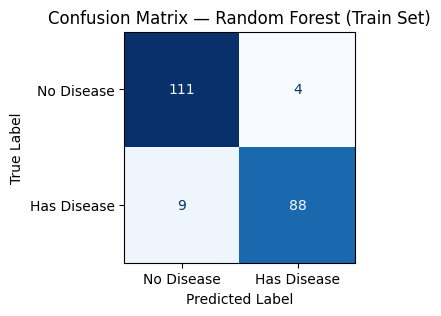

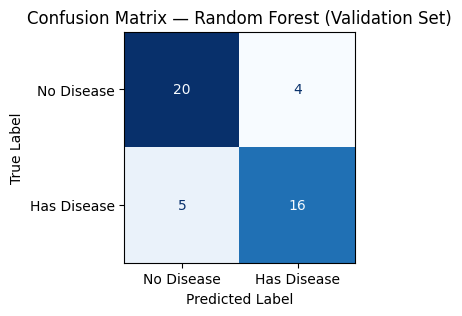

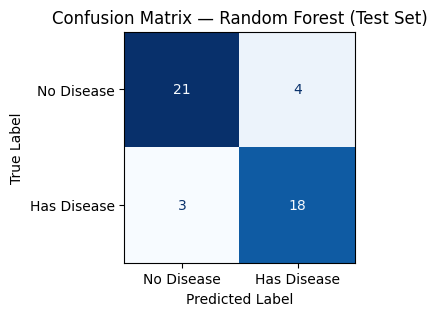

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
Train Set,0.9387,0.9408,0.9362,0.9379,0.9385,0.2260
Validation Set,0.8000,0.8000,0.7976,0.7984,0.7996,0.4255
Test Set,0.8478,0.8466,0.8486,0.8472,0.8480,0.3478


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, log_loss, classification_report, 
    confusion_matrix
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# -------------------------
# 1. Split the data (70 / 15 / 15)
# -------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# -------------------------
# 2. Train model
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# -------------------------
# 3. Function to compute metrics
# -------------------------
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision (macro)": precision_score(y, y_pred, average='macro'),
        "Recall (macro)": recall_score(y, y_pred, average='macro'),
        "F1 (macro)": f1_score(y, y_pred, average='macro'),
        "F1 (weighted)": f1_score(y, y_pred, average='weighted'),
        "Log Loss": log_loss(y, y_proba),
    }
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Has Disease'])
    fig, ax = plt.subplots(figsize=(3, 3))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — Random Forest ({dataset_name})", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return metrics

# -------------------------
# 4. Evaluate on all sets
# -------------------------
results = []
results.append(evaluate_model(rf_model, X_train, y_train, "Train Set"))
results.append(evaluate_model(rf_model, X_val, y_val, "Validation Set"))
results.append(evaluate_model(rf_model, X_test, y_test, "Test Set"))

# -------------------------
# 5. Combine into a single summary table
# -------------------------
df_results = pd.DataFrame(results).set_index("Dataset")
display(df_results.round(4))


The overall performance is clinically meaningful and statistically stable, making this model a reliable baseline for heart disease risk prediction.